# Semi-automated high content analysis of pollen performance using TubeTracker — minimal Colab demo

**Paper:** "Semi-automated high content analysis of pollen performance using tubetracker", *Plant Reproduction* 38(3):16, 2025 (DOI [10.1007/s00497-025-00526-0](https://doi.org/10.1007/s00497-025-00526-0)); full text verified from the authors' bioRxiv preprint v1 (DOI 10.1101/2024.11.21.624782).
**Author code:** github.com/souonkap/TubeTracker, pinned commit `271d2d5061f7861529719be54476081059e42383` (Brown University, non-commercial license notice; see below).

**Scope (PARTIAL DEMONSTRATION):** run the authors' own TubeTracker pipeline headless on their bundled example `sample_movie.avi`: segmentation, pollen-grain detection, tube-tip detection (segment-edge method), tip-overlap germination calling, and tube-tip elongation tracking. This is a one-example software demonstration of the core pipeline — **not** a replication of the paper's six-cultivar validation (cultivar movies and R analysis scripts are not public).

**実行内容（日本語）:** 著者公開の TubeTracker を、同梱サンプル動画 `sample_movie.avi` に対してヘッドレス実行します。セグメンテーション → 花粉粒検出 → 先端検出（segment-edge 法）→ 発芽判定（tip-overlap 法）→ 伸長トラッキング（motpy）。6 品種検証の再現ではなく、最小例による動作デモです。

**AI-assisted adaptation notice / AI による適応の説明:** The authors provide a wxPython **GUI** application, not a Colab implementation. This notebook reuses the authors' computational classes **verbatim** (extracted from the pinned `TubeTracker.py` at runtime) and re-implements only the GUI's file-loading sequence headless. The executed example and checks below were validated, but untested GUI-only behavior is not guaranteed. 著者は GUI のみを提供しており、本ノートブックは同一リビジョンの計算クラスをそのまま再利用し、GUI の読み込み操作のみをヘッドレス化したものです。

**Runtime:** **CPU only** (menu: Runtime → Change runtime type → **CPU**). The method is classical OpenCV + motpy; no GPU is used. Expected total: ~10–20 min including setup and a ~3.6 MB download. **Run all** to execute everything.


## 1. Environment check
Report the Python/OpenCV versions actually used. OpenCV must include the **contrib** module `ximgproc` (used by the authors' skeleton-edge tip detector).
環境確認：OpenCV の contrib モジュール（`ximgproc`）が必要です。


In [ ]:
import sys, importlib
print("python:", sys.version.split()[0])
try:
    import cv2
    print("cv2:", cv2.__version__, "| ximgproc available:", hasattr(cv2, "ximgproc"))
except Exception as e:
    print("cv2 import failed:", e)

python: 3.13.15
cv2: 4.14.0 | ximgproc available: True


## 2. Install dependencies
`opencv-contrib-python` provides `cv2.ximgproc`; `motpy` is the multi-object tracker used by the authors (`from motpy import ... Detection, MultiObjectTracker` in `TubeTracker.py`). pandas/numpy are preinstalled on Colab.
依存関係：opencv-contrib-python と motpy をインストールします。


In [ ]:
%pip uninstall -y -q opencv-python
%pip install -q opencv-contrib-python motpy
import cv2, motpy, pandas, numpy
print("cv2:", cv2.__version__, "| ximgproc:", hasattr(cv2, "ximgproc"))
print("motpy:", getattr(motpy, "__version__", "unknown"))

cv2: 4.14.0 | ximgproc: True
motpy: unknown


## 3. Fetch pinned author code and the example movie
Both files are downloaded from the **pinned commit** `271d2d5061f7861529719be54476081059e42383` of `souonkap/TubeTracker` and verified: `sample_movie.avi` must be exactly 3,566,152 bytes with git blob hash `525e55195c08d0c2da721a64d26f9c3c7ce74aa9`; `TubeTracker.py` blob `2ab2d65d4d68ba48a05979427ea0b4ac69cc25bf`. The movie is the authors' bundled sample input (dataset bytes stay in this Colab VM only).
著者コードとサンプル動画を固定コミットから取得し、サイズと git blob ハッシュで検証します。


In [ ]:
import urllib.request, hashlib, os

COMMIT = "271d2d5061f7861529719be54476081059e42383"
def fetch(name, expected_size, expected_blob):
    url = f"https://raw.githubusercontent.com/souonkap/TubeTracker/{COMMIT}/{name}"
    dst = "/content/" + name
    urllib.request.urlretrieve(url, dst)
    data = open(dst, "rb").read()
    blob = hashlib.sha1(b"blob %d\0" % len(data) + data).hexdigest()
    sha256 = hashlib.sha256(data).hexdigest()
    assert len(data) == expected_size, (name, len(data), expected_size)
    assert blob == expected_blob, (name, blob, expected_blob)
    print(f"{name}: {len(data)} bytes, blob OK, sha256={sha256}")
    return dst

code_path = fetch("TubeTracker.py", 140345, "2ab2d65d4d68ba48a05979427ea0b4ac69cc25bf")
movie_path = fetch("sample_movie.avi", 3566152, "525e55195c08d0c2da721a64d26f9c3c7ce74aa9")

TubeTracker.py: 140345 bytes, blob OK, sha256=fc8b8776b1428caefd5c46a9987f5c0585c13725631d00fb8bc962490f6e82b9
sample_movie.avi: 3566152 bytes, blob OK, sha256=4333afee5ac3e63abdd6ca0c416d33bc79485733345904ef657a061b8e4b8842


## 4. Load the authors' computational classes verbatim
`TubeTracker.py` is a wxPython GUI app. We parse it with `ast` and execute **only** the GUI-free classes exactly as written — `Detections`, `Point`, `ROI`, `Track`, `Tracker` — plus the module-level `temp_dir` they rely on. The wx GUI classes (`Screen`, `Screen_Control`, `Tracker_GUI`, `main`) and the `import wx` lines are the only code excluded. No author computation is rewritten.
`TubeTracker.py` から GUI 非依存の計算クラスを AST で**そのまま**抽出して実行します（wx GUI 部分のみ除外）。


In [ ]:
import ast, tempfile, random

src = open("/content/TubeTracker.py").read()
WANT = {"Detections", "Point", "ROI", "Track", "Tracker"}
tree = ast.parse(src)
segments = [ast.get_source_segment(src, node) for node in tree.body
            if isinstance(node, ast.ClassDef) and node.name in WANT]
assert sorted({n.name for n in tree.body
               if isinstance(n, ast.ClassDef) and n.name in WANT}) == sorted(WANT)
print("extracted classes:", sorted(WANT))

temp_dir = tempfile.mkdtemp(prefix="tubetracker_")
ns = dict(
    os=__import__("os"), io=__import__("io"), csv=__import__("csv"),
    math=__import__("math"), shutil=__import__("shutil"),
    cv=__import__("cv2"), np=__import__("numpy"),
    pd=__import__("pandas"), stat=__import__("statistics"),
    glob=__import__("glob").glob, join=__import__("os").path.join,
    Path=__import__("pathlib").Path, randint=__import__("random").randint,
    tempdir=tempfile.TemporaryDirectory(), temp_dir=temp_dir,
    random=random,
)
from motpy import Box, Detection, MultiObjectTracker
ns.update(Box=Box, Detection=Detection, MultiObjectTracker=MultiObjectTracker)
for seg in segments:
    exec(compile(seg, "TubeTracker.py", "exec"), ns)
Detections, Point, ROI, Track, Tracker = (ns[k] for k in ["Detections", "Point", "ROI", "Track", "Tracker"])
print("author classes ready; temp_dir =", temp_dir)

extracted classes: ['Detections', 'Point', 'ROI', 'Track', 'Tracker']
author classes ready; temp_dir = /tmp/tubetracker_js1rq4am


## 5. Extract the movie's frames (replicating the GUI load step)
The GUI (`Tracker_GUI` data-directory handler) reads every frame with `cv.VideoCapture`, resizes it to the tracker screen size (1000, 800), writes it as PNG, and sets `tracker.img_rp = Point(1000/w, 800/h)`. We reproduce exactly that sequence, without rotation (the GUI default).
GUI の読み込み処理（VideoCapture → 1000×800 へリサイズ → PNG 保存 → img_rp 設定）をそのまま再現します。


In [ ]:
import cv2, os

cap = cv2.VideoCapture("/content/sample_movie.avi")
assert cap.isOpened(), "could not open sample_movie.avi"
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
print(f"sample_movie.avi: {n_frames} frames @ {fps} fps ({n_frames/max(fps,1e-9):.1f} s)")

INPUT_DIR = "/content/tubetracker_input"
os.makedirs(INPUT_DIR, exist_ok=True)
file_names = []
k = -1
while True:
    k += 1
    ret, frame = cap.read()
    if not ret:
        break
    if k == 0:
        h, w, _ = frame.shape
        img_rp = Point(x=1000 / w, y=800 / h)  # GUI default (no rotation)
    xx = f"{INPUT_DIR}/frame_{k:04d}.png"
    cv2.imwrite(xx, cv2.resize(frame, (1000, 800)))
    file_names.append(xx)
cap.release()
assert len(file_names) == n_frames, (len(file_names), n_frames)
print("frames written:", len(file_names), "first:", file_names[0], "img_rp:", img_rp.x, img_rp.y)

sample_movie.avi: 129 frames @ 15.0 fps (8.6 s)


frames written: 129 first: /content/tubetracker_input/frame_0000.png img_rp: 0.78125 0.78125


## 6. Show one input frame
Preview of the (resized) brightfield input before running the pipeline.
入力フレームのプレビューです。


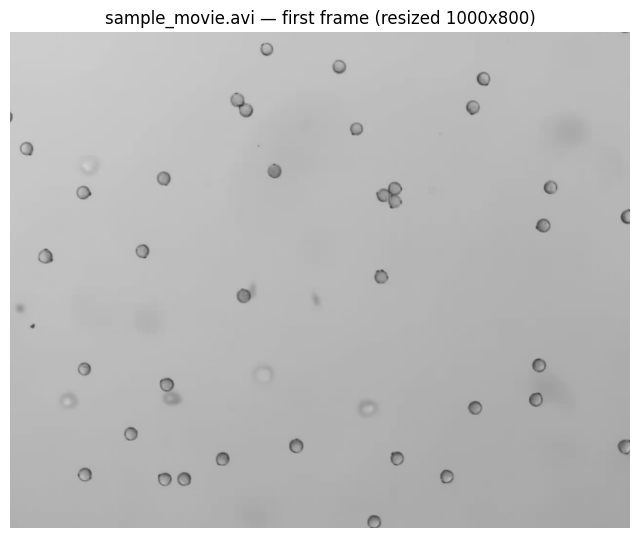

In [ ]:
import cv2, matplotlib.pyplot as plt

img = cv2.cvtColor(cv2.imread(file_names[0]), cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 6.5)); plt.imshow(img); plt.title("sample_movie.avi — first frame (resized 1000x800)")
plt.axis("off"); plt.show()

## 7. Run the TubeTracker pipeline (author defaults)
Executed in the same order as the GUI's analysis actions: `segment_inputs` → `find_grains` (Hough circles + motpy) → `find_tips_se` (segment-edge tips) → `track_germination_via_tips` (tip-overlap germination) → `track_elongation` (motpy tip tracks). All parameters are the authors' defaults from `Tracker.__init__`. Progress prints come from the author code itself.
GUI と同じ順序で著者デフォルトのパラメータのまま実行します（進行表示は著者コードのもの）。


In [ ]:
import time

tracker = Tracker()
tracker.file_names = file_names
tracker.img_rp = img_rp

t0 = time.time(); tracker.segment_inputs();        print(f"segment_inputs done in {time.time()-t0:.1f} s")
t0 = time.time(); tracker.find_grains();           print(f"find_grains: {len(tracker.valid_grains)} grains in {time.time()-t0:.1f} s")
t0 = time.time(); tracker.find_tips_se();          print(f"find_tips_se: {sum(len(t) for t in tracker.valid_tips)} tip detections in {time.time()-t0:.1f} s")
t0 = time.time(); tracker.track_germination_via_tips(); print(f"germination via tips in {time.time()-t0:.1f} s")
t0 = time.time(); tracker.track_elongation();      print(f"track_elongation: {len(tracker.valid_tracks)} tip tracks in {time.time()-t0:.1f} s")

segment_inputs done in 3.7 s


find_grains: 33 grains in 2.7 s


Frame: 0; tips: 2


Frame: 1; tips: 7


Frame: 2; tips: 2


...

Frame: 125; tips: 23


Frame: 126; tips: 18


Frame: 127; tips: 26


Frame: 128; tips: 21
find_tips_se: 2623 tip detections in 54.4 s
Frame: 0, ungerminated: 33
Frame: 1, ungerminated: 33
Frame: 2, ungerminated: 33
Frame: 3, ungerminated: 33
Frame: 4, ungerminated: 33
Frame: 5, ungerminated: 33
Frame: 6, ungerminated: 33
Frame: 7, ungerminated: 30
Frame: 8, ungerminated: 30
Frame: 9, ungerminated: 29
Frame: 10, ungerminated: 29
Frame: 11, ungerminated: 29
Frame: 12, ungerminated: 26
Frame: 13, ungerminated: 24
Frame: 14, ungerminated: 22
Frame: 15, ungerminated: 22
Frame: 16, ungerminated: 22
Frame: 17, ungerminated: 21
Frame: 18, ungerminated: 20
Frame: 19, ungerminated: 20
Frame: 20, ungerminated: 20
Frame: 21, ungerminated: 20
Frame: 22, ungerminated: 19
Frame: 23, ungerminated: 19
Frame: 24, ungerminated: 19
Frame: 25, ungerminated: 19
Frame: 26, ungerminated: 19
Frame: 27, ungerminated: 19
Frame: 28, ungerminated: 18
Frame: 29, ungerminated: 18
Frame: 30, ungerminated: 18
Frame: 31, ungerminated: 17
Frame: 32, ungerminated: 17
Frame: 33, ungerminat

track_elongation: 109 tip tracks in 2.0 s


## 8. Germination results
Each tracked grain's germination frame (from `update_germination`, method `tip_overlap`) as time in seconds, using the code default `time_p_frame = 60` s per frame. Note the unit caveat below.
発芽結果：各花粉粒の発芽フレーム（tip_overlap 法）。時間はコード既定の 60 秒/フレーム換算です。


In [ ]:
import pandas as pd

rows = []
for g in tracker.valid_grains:
    rows.append({"grain_id": g.id, "germinated": g.is_germinated,
                 "germination_frame": g.ger_frame if g.is_germinated else None,
                 "germination_time_s": (g.ger_frame * tracker.time_p_frame) if g.is_germinated else None,
                 "p_value": g.ger_p_value})
germination = pd.DataFrame(rows)
print(f"{len(germination)} tracked grains; {int(germination.germinated.sum())} germinated via tip-overlap")
germination

33 tracked grains; 25 germinated via tip-overlap


,grain_id,germinated,germination_frame,germination_time_s,p_value
0,1,False,NaN,NaN,1.000
1,2,True,6.0,360.0,0.045
2,3,True,30.0,1800.0,0.045
3,4,True,34.0,2040.0,0.045
4,5,True,16.0,960.0,0.045
5,6,True,11.0,660.0,0.045
6,7,False,NaN,NaN,1.000
7,8,False,NaN,NaN,1.000
8,9,True,17.0,1020.0,0.045
9,10,True,13.0,780.0,0.045


## 9. Elongation results
Save the authors' result files (`save_results`, as the GUI does) and summarize the tip tracks. Length/velocity use the code defaults (`pxl_dis = 1.00`, `dis_unit = "um"`, `time_p_frame = 60 s`) — **uncalibrated**: the pixel-to-µm calibration for this movie is not published, so "um" values are per-default-pixel units.
伸長結果：著者の `save_results` を呼び出して結果 CSV を保存し、要約します。較正は未指定のため、長さ・速度はコード既定単位である点に注意してください。


In [ ]:
import os, pandas as pd

OUT = "/content/tubetracker_results/"
os.makedirs(OUT, exist_ok=True)
tracker.save_results(OUT)
print(sorted(os.listdir(OUT)))

tracks_raw = pd.read_csv(OUT + "tracks.raw.data.csv")
summary = (tracks_raw[tracks_raw.track_id.astype(str) != "track_id"]
           .groupby("track_id").agg(n_points=("frame", "size"),
                                    length_px=("length (pixel)", "max"),
                                    first_frame=("frame", "min"), last_frame=("frame", "max")))
print(summary.to_string())

['survival.avi', 'survival.curves.csv', 'survival.raw.data.csv', 'tip.tracks.avi', 'tracks.raw.data.csv', 'tracks.synchronized.csv', 'tracks.unsynchronized.csv']
          n_points   length_px  first_frame  last_frame
track_id                                               
1               11   13.330193            1          11
2               58  128.509389            5          62
3               21   19.510580            5          25
4               24   25.160773            6          29
5               44   96.832565            6          49
6               65  159.209042            6          70
7               14   23.412837            8          21
8               57   83.600328            8          64
9               11   23.059635            9          19
10              37   52.214294            9          45
11              12    2.560000           11          22
12              20   39.205080           11          30
13              47   84.824245           11          5

## 10. Visualization — input vs. tracked overlay, and germination timing
The overlay is the authors' own `draw_results` (track IDs and paths). The germination-time distribution is an additional visualization created for this notebook (not an author figure), from the tip-overlap germination calls above.
可視化：著者の `draw_results` によるトラック描画と、本ノートブックで追加した発芽時間の分布図（著者図ではありません）。


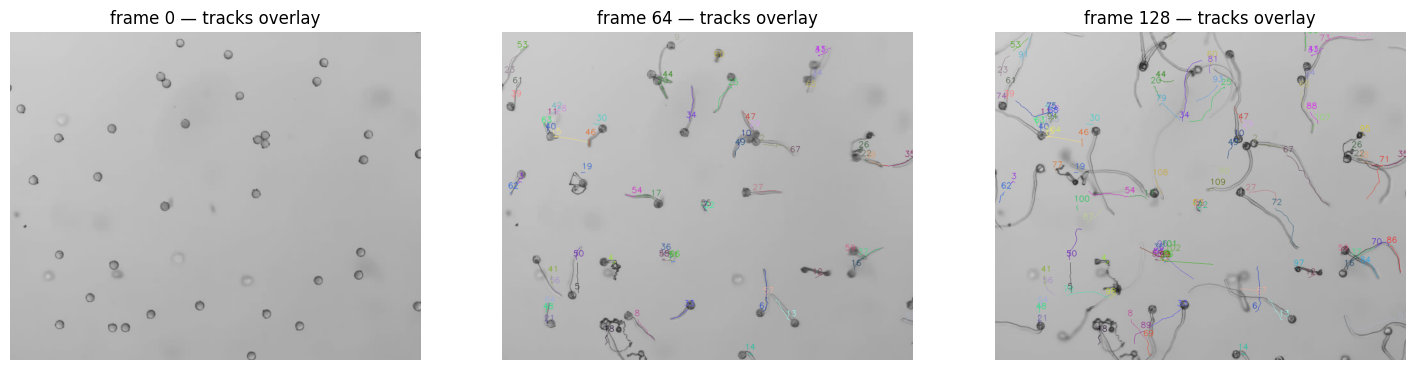

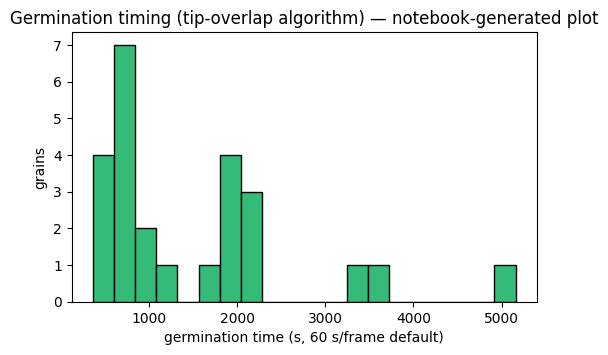

In [ ]:
import numpy as np, matplotlib.pyplot as plt

img_list = tracker.draw_results()  # author overlay for all frames
sel = sorted(set([0, len(img_list)//2, len(img_list)-1]))
fig, axes = plt.subplots(1, len(sel), figsize=(6*len(sel), 5.5))
for ax, i in zip(np.atleast_1d(axes), sel):
    ax.imshow(cv2.cvtColor(img_list[i], cv2.COLOR_BGR2RGB))
    ax.set_title(f"frame {i} — tracks overlay"); ax.axis("off")
del img_list
plt.show()

germ = germination[germination.germinated]
fig, ax = plt.subplots(figsize=(6, 3.5))
if len(germ):
    ax.hist(germ.germination_time_s, bins=20, color="#3b7", edgecolor="k")
ax.set_xlabel("germination time (s, 60 s/frame default)"); ax.set_ylabel("grains")
ax.set_title("Germination timing (tip-overlap algorithm) — notebook-generated plot")
plt.show()

## 11. Interpretation and limitations
**What this demonstrates:** the authors' full automatic pipeline (segmentation → grain detection → segment-edge tips → tip-overlap germination → motpy elongation tracking) runs end-to-end on their bundled example movie, producing per-grain germination calls and per-tip tracks/CSVs — the same artifacts the GUI writes.

**Limitations / 既知の限界:**
- One example movie; **not** the paper's six-cultivar validation (cultivar movies, raw quantifications and the R analysis are not public).
- Length/velocity values are in **default code units** (`pxl_dis=1.00`, `dis_unit="um"`, 60 s/frame); no pixel-to-µm calibration is published for this movie.
- The manual curation GUI features (adding tips, cut/extend tracks, survival/rupture annotation) are out of scope; survival results are therefore not produced.
- Journal-version wording (Plant Reproduction 38(3):16) was not readable; evidence is the bioRxiv v1 preprint + pinned code.
- License: Brown University non-commercial permission notice (not an OSI license) — educational use only.

## References
- TubeTracker, commit `271d2d5061f7861529719be54476081059e42383` (souonkap/TubeTracker).
- Paper: DOI 10.1007/s00497-025-00526-0 (Plant Reproduction 38(3):16, 2025); bioRxiv 10.1101/2024.11.21.624782v1.
- motpy: https://github.com/wmgeolab/motpy (author import), opencv-contrib: https://github.com/opencv/opencv_contrib
